<a href="https://colab.research.google.com/github/Ivanfongw5/AMS_517_Final_Project/blob/main/kolm_ritter_replication_mcgarry_wu_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RL Option Hedging Replication of Kolm and Ritter (2019)

Run cells top to bottom with Shift+Enter.
Steps: install deps → upload files → smoke-test → full run → view plots → download.

##1 — Install dependencies

In [ ]:
!pip install gymnasium scipy matplotlib numpy torch --quiet

##2 — Upload the 4 project files (agent, evalute, train, trading_env)

In [ ]:
from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving agent.py to agent.py
Saving evaluate.py to evaluate.py
Saving train.py to train.py
Saving trading_env.py to trading_env (1).py
Uploaded: ['agent.py', 'evaluate.py', 'train.py', 'trading_env (1).py']


##3 — Verify files are present

In [ ]:
import os
required = ["trading_env.py", "agent.py", "evaluate.py", "train.py"]
for f in required:
    status = "OK" if os.path.exists(f) else "MISSING"
    print(status, f)

OK trading_env.py
OK agent.py
OK evaluate.py
OK train.py


##4 — Test Run

Runs 3 batches x 500 episodes to verify experiment works before running full simulation.

In [ ]:
!python train.py --fast --out_dir results_fast

[FAST MODE] Using 3 batches × 500 episodes for quick testing. --n_eval ignored.
Kolm & Ritter (2019) — RL Option Hedging Replication
  S0=100.0, K=100.0, T=10d, D=5/day => 50 steps/ep
  sigma=0.01, kappa=0.1
  multiplier=5.0, seed=42
  batches=3, episodes/batch=500
  total transitions=75,000

[Training RL agent...]
Batch 1/3 | eps=1.000 | buffer=25,000 | avg_ep_reward=-113603.1236 | fit_loss=15984618.361538
Batch 2/3 | eps=0.525 | buffer=25,000 | avg_ep_reward=-58474.0309 | fit_loss=5486295.684615
Batch 3/3 | eps=0.050 | buffer=25,000 | avg_ep_reward=-7409.2502 | fit_loss=652256.776202
Training complete.
Model saved to results_fast/q_network.pt

[Evaluating...]
Saved: results_fast/exhibit1_rl_frictionless.png
Saved: results_fast/exhibit2_delta_friction.png
Saved: results_fast/exhibit3_rl_friction.png

Running 200 out-of-sample episodes for Exhibits 4 & 5 ...
Saved: results_fast/exhibit4_kde_cost_vol.png

Exhibit 4 results:
  Cost: delta_mean=378.5962, rl_mean=147.4590
  Cost t-stat=28.

##5 — Test plots

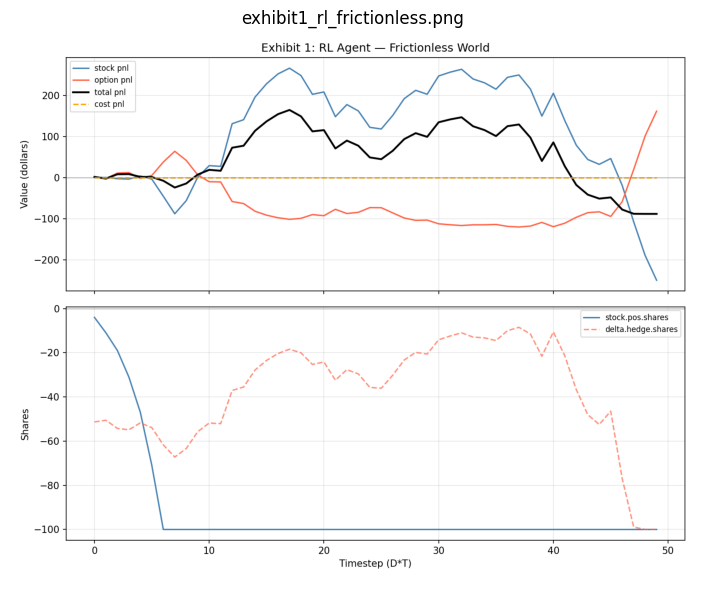

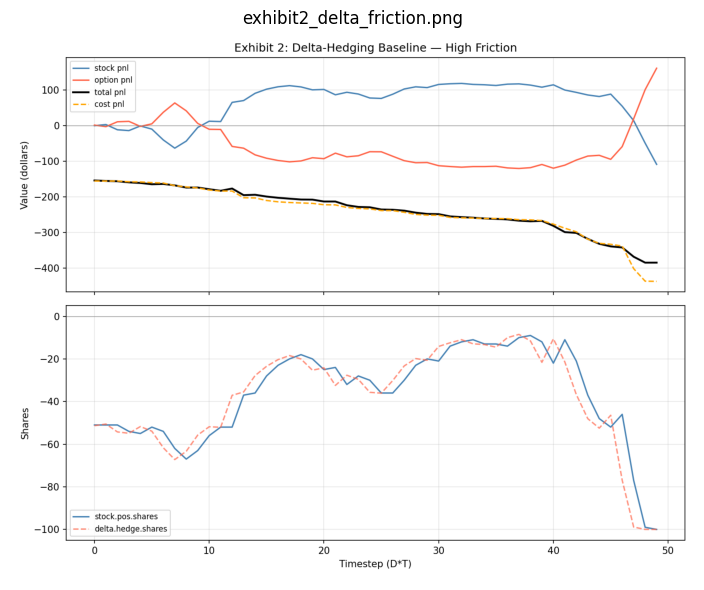

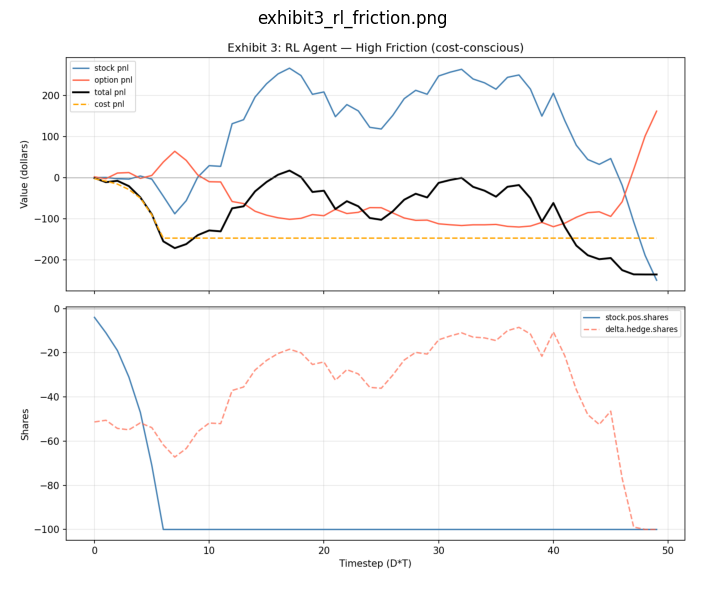

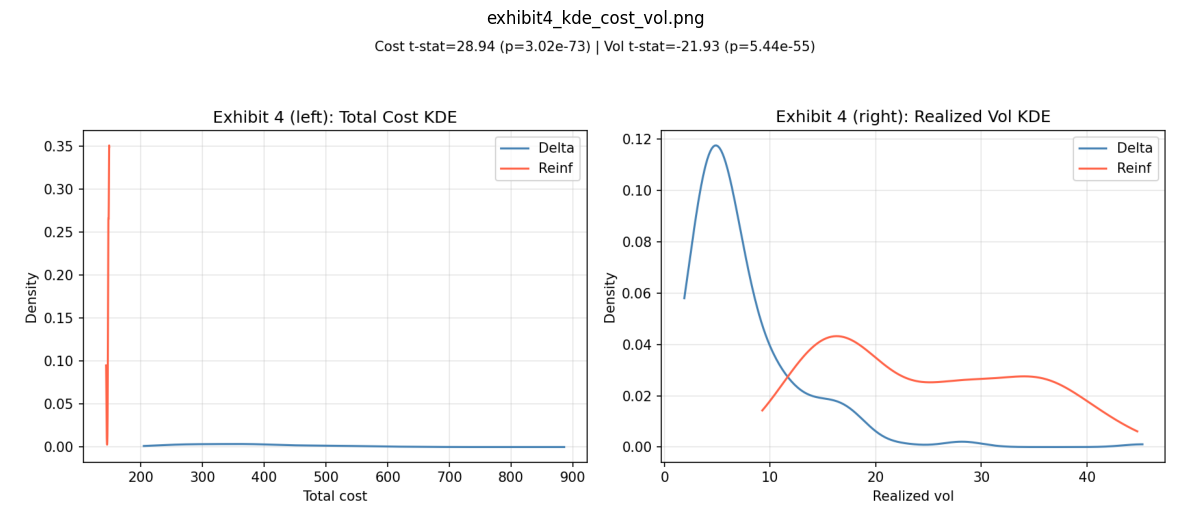

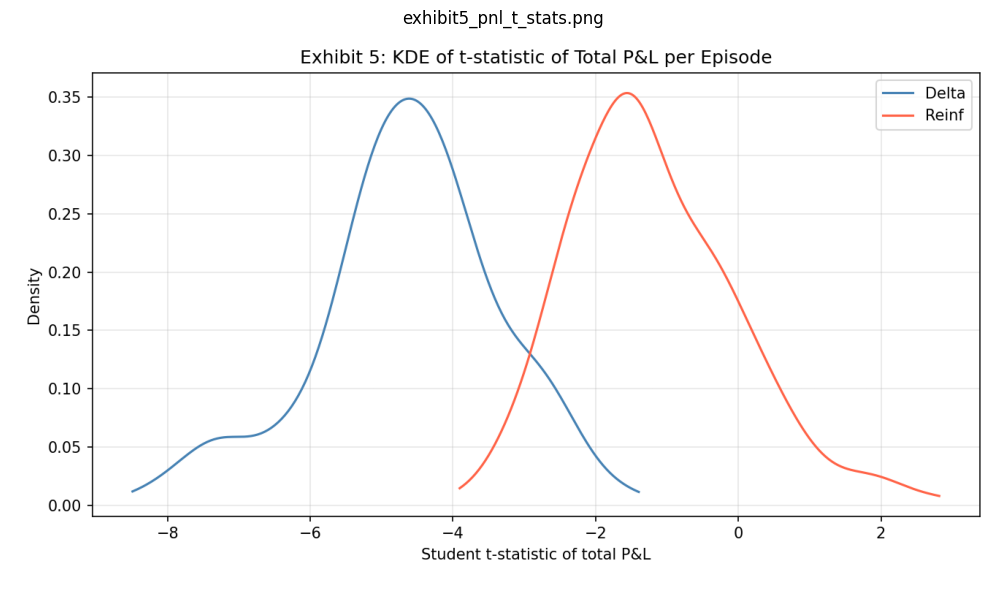

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob, os

for path in sorted(glob.glob("results_fast/*.png")):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(mpimg.imread(path))
    ax.axis("off")
    ax.set_title(os.path.basename(path))
    plt.tight_layout()
    plt.show()

## Step 6 — Full experiment (56 minutes)

Run on T4 GPU

In [ ]:
!python train.py --multiplier 5 --n_eval 10000 --out_dir results_full --seed 42

Kolm & Ritter (2019) — RL Option Hedging Replication
  S0=100.0, K=100.0, T=10d, D=5/day => 50 steps/ep
  sigma=0.01, kappa=0.1
  multiplier=5.0, seed=42
  batches=5, episodes/batch=15,000
  total transitions=3,750,000

[Training RL agent...]
Batch 1/5 | eps=1.000 | buffer=750,000 | avg_ep_reward=-114908.3986 | fit_loss=2253789.434281
Batch 2/5 | eps=0.762 | buffer=750,000 | avg_ep_reward=-89329.3268 | fit_loss=10957266.456403
Batch 3/5 | eps=0.525 | buffer=750,000 | avg_ep_reward=-60163.0325 | fit_loss=8835027.165940
Batch 4/5 | eps=0.288 | buffer=750,000 | avg_ep_reward=-33369.9486 | fit_loss=5505834.357016
Batch 5/5 | eps=0.050 | buffer=750,000 | avg_ep_reward=-7124.3497 | fit_loss=1138541.951541
Training complete.
Model saved to results_full/q_network.pt

[Evaluating...]
Saved: results_full/exhibit1_rl_frictionless.png
Saved: results_full/exhibit2_delta_friction.png
Saved: results_full/exhibit3_rl_friction.png

Running 10,000 out-of-sample episodes for Exhibits 4 & 5 ...
  1,000/10

##7 — Full results plots

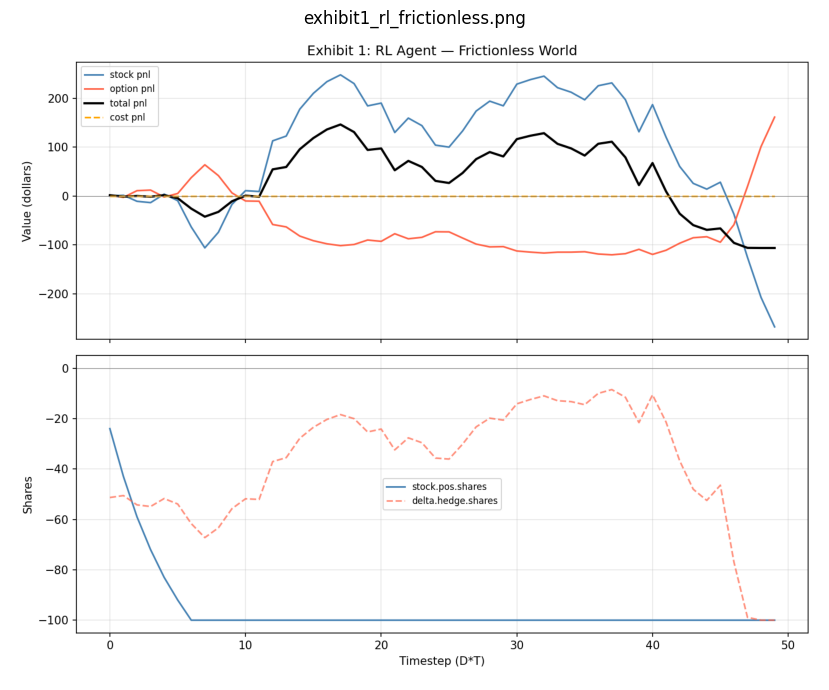

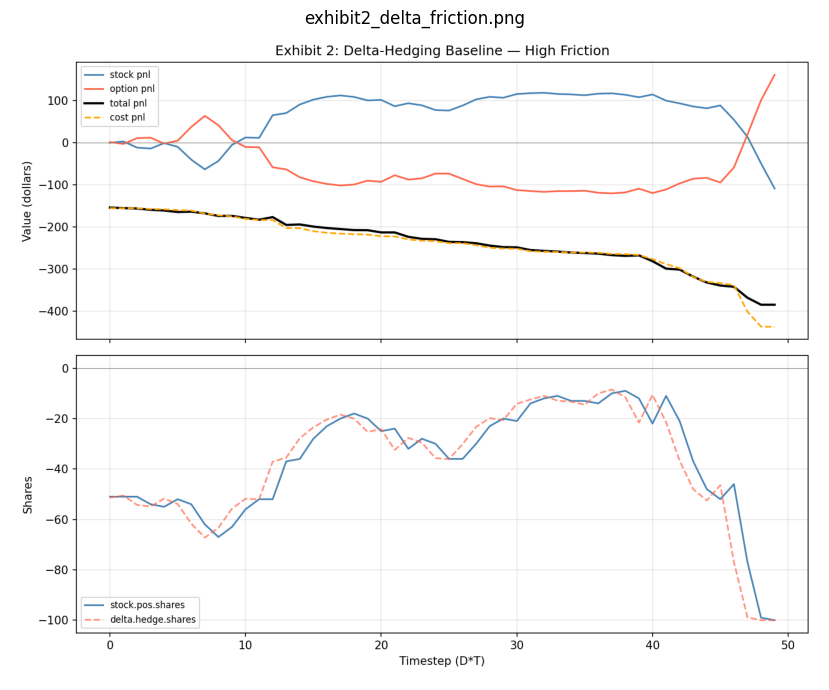

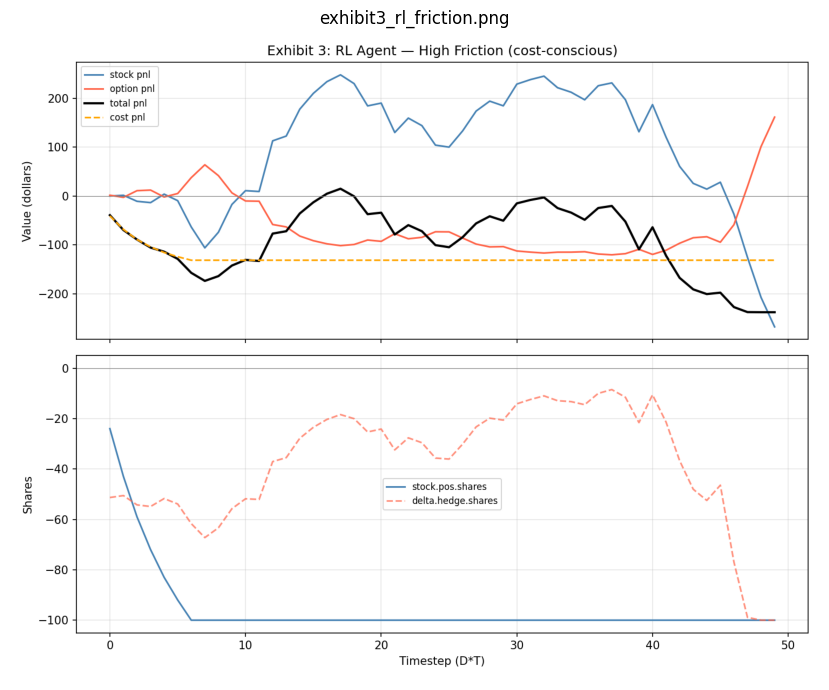

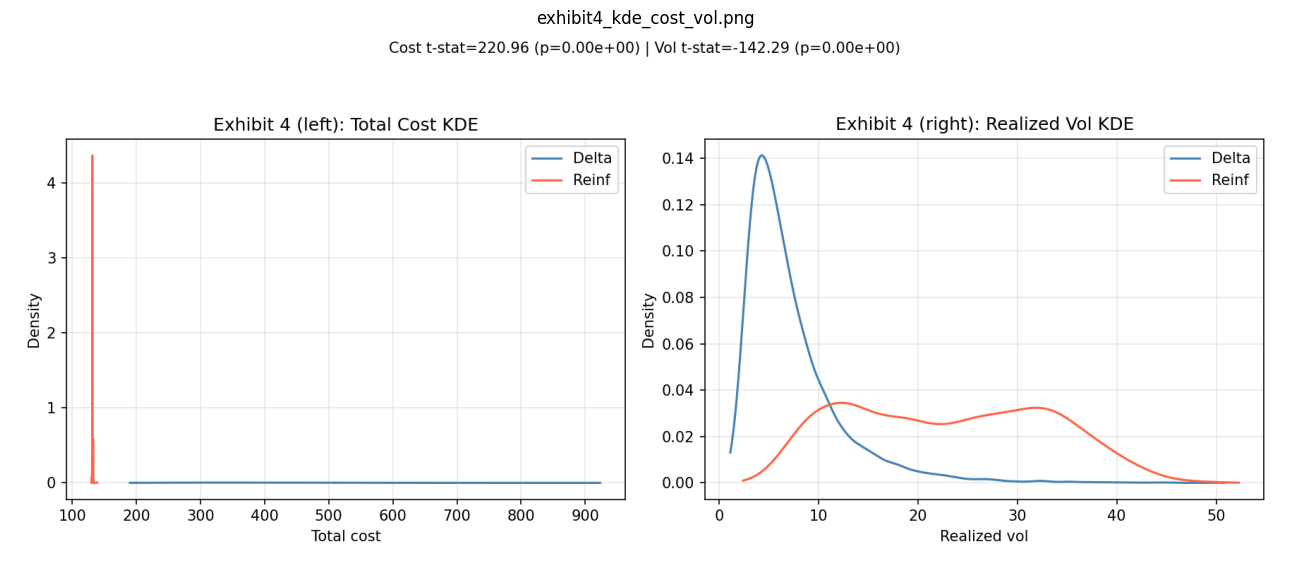

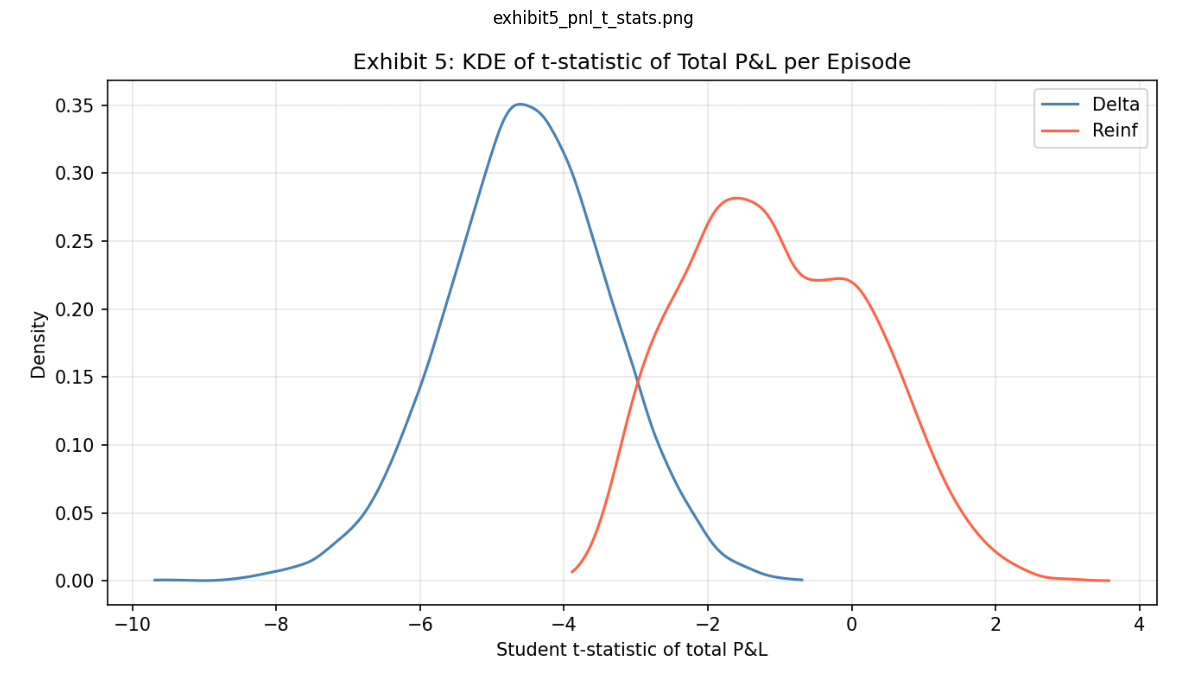

In [ ]:
for path in sorted(glob.glob("results_full/*.png")):
    fig, ax = plt.subplots(figsize=(13, 7))
    ax.imshow(mpimg.imread(path))
    ax.axis("off")
    ax.set_title(os.path.basename(path))
    plt.tight_layout()
    plt.show()

##8 — Downloads results

In [ ]:
import shutil
from google.colab import files
shutil.make_archive("kolm_ritter_results", "zip", "results_full")
files.download("kolm_ritter_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sys
sys.path.insert(0, ".")
from trading_env import OptionHedgingEnv
from agent import FittedQAgent

env = OptionHedgingEnv(S0=100, K=100, T=10, D=5, sigma=0.01, kappa=0.1, multiplier=5)
agent = FittedQAgent(env, seed=None)
agent.load("results_full/q_network.pt")

obs, _ = env.reset(seed=99)
total_pnl = 0
print(f"{'Step':>4} {'S':>8} {'tau':>6} {'n':>5} {'trade':>6} {'dw':>8} {'cum_pnl':>10}")
print("-" * 60)
while True:
    action = agent.act(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    total_pnl += info["dw"]
    print(f"{env._step:>4} {info['S']:>8.3f} {info['tau']:>6.2f} {info['n']:>5} {info['trade']:>6} {info['dw']:>8.4f} {total_pnl:>10.4f}")
    if terminated or truncated:
        break
print(f"Final P&L: {total_pnl:.4f}")